In [1]:
from dotenv import load_dotenv

load_dotenv()

True

# Streaming e Deploy

Quando a gente usa um agente de IA, ele pode levar vários segundos para responder. Nesse tempo, o usuário fica olhando pra uma tela em branco, sem saber se algo travou ou se está tudo funcionando. Isso é péssimo pra experiência.

**Streaming** resolve esse problema: em vez de esperar a resposta completa, a gente vai recebendo pedaços dela em tempo real. É exatamente o que o ChatGPT faz quando "digita" a resposta palavra por palavra. Neste notebook, vamos explorar os diferentes modos de streaming do LangGraph e, no final, colocar tudo isso em produção com **FastAPI** e **Streamlit**.

In [2]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage

Pra deixar o exemplo mais realista, vamos criar duas tools com um `time.sleep(1)` cada. Esse delay artificial simula a latência de uma API externa e vai deixar bem claro a diferença entre usar e não usar streaming.

In [3]:
@tool
def consultar_clima(cidade: str) -> str:
    """Consulta a previsão do tempo para uma cidade."""
    import time
    time.sleep(1)  # simular latência de API
    previsoes = {
        "são paulo": "25°C, parcialmente nublado, umidade 65%",
        "rio de janeiro": "32°C, ensolarado, umidade 45%",
        "curitiba": "15°C, chuva leve, umidade 80%",
    }
    return previsoes.get(cidade.lower(), f"Previsão não disponível para {cidade}.")


@tool
def buscar_restaurantes(cidade: str, tipo: str) -> str:
    """Busca restaurantes em uma cidade por tipo de culinária."""
    import time
    time.sleep(1)
    return f"3 restaurantes de {tipo} encontrados em {cidade}: Restaurante A, Restaurante B, Restaurante C."

In [4]:
agente = create_agent(
    model="gpt-4.1-nano",
    tools=[consultar_clima, buscar_restaurantes],
    system_prompt="Você é um assistente de viagem. Responda em português.",
)

## O problema: sem streaming

Vamos começar pelo jeito "normal" de invocar o agente, com `.invoke()`. Repare que a gente vai medir o tempo total de execução. O ponto aqui é simples: durante esses segundos, o usuário não vê absolutamente nada.

In [5]:
# Sem streaming: espera TUDO terminar antes de ver qualquer coisa
import time

inicio = time.time()
resposta = agente.invoke(
    {"messages": [HumanMessage(content="Como está o tempo em São Paulo? Sugira restaurantes japoneses lá.")]}
)
fim = time.time()

print(f"Tempo total: {fim - inicio:.1f}s")
print(resposta["messages"][-1].content)

Tempo total: 3.5s
O clima em São Paulo está parcialmente nublado, com temperatura de 25°C e umidade de 65%. Quanto aos restaurantes japoneses, há três opções na cidade: Restaurante A, Restaurante B e Restaurante C. Se desejar, posso fornecer mais informações sobre algum desses restaurantes ou ajudá-lo a fazer uma reserva.


Olha só: 4 segundos de espera total. Nesse tempo inteiro, a interface ficaria congelada. Agora imagina isso numa aplicação real, com ferramentas que demoram ainda mais. Precisamos de uma forma melhor.

## Modos de streaming

O LangGraph oferece diferentes **modos de streaming** via o método `.stream()`. Cada modo entrega as informações de um jeito diferente, dependendo do nível de detalhe que você precisa.

### Modo `values`

O modo `values` entrega um **snapshot completo** do estado do grafo após cada nó executar. É como tirar uma foto do estado inteiro a cada passo. Útil pra debug, mas transmite mais dados do que o necessário.

In [6]:
# Modo VALUES: snapshot completo do estado após cada nó
for chunk in agente.stream(
    {"messages": [HumanMessage(content="Qual o clima em Curitiba?")]},
    stream_mode="values",
):
    print(f"--- Snapshot ({len(chunk['messages'])} mensagens) ---")
    print(f"Última: {chunk['messages'][-1].type}: {chunk['messages'][-1].content[:100]}")
    print()

--- Snapshot (1 mensagens) ---
Última: human: Qual o clima em Curitiba?

--- Snapshot (2 mensagens) ---
Última: ai: 

--- Snapshot (3 mensagens) ---
Última: tool: 15°C, chuva leve, umidade 80%

--- Snapshot (4 mensagens) ---
Última: ai: O clima em Curitiba está com temperatura de aproximadamente 15°C, com chuva leve e umidade em torno 



### Modo `updates`

Diferente do `values`, o modo `updates` entrega apenas o **delta** -- ou seja, só o que mudou em cada nó. Isso é mais eficiente e mostra exatamente qual nó produziu qual resultado. Repare que agora a gente consegue ver as tool calls separadas da resposta final.

In [7]:
# Modo UPDATES: apenas o delta de cada nó
for chunk in agente.stream(
    {"messages": [HumanMessage(content="Qual o clima em Curitiba?")]},
    stream_mode="updates",
):
    for node_name, update in chunk.items():
        print(f"Node: {node_name}")
        if "messages" in update:
            for msg in update["messages"]:
                print(f"  {msg.type}: {msg.content[:100]}")
                if hasattr(msg, "tool_calls") and msg.tool_calls:
                    print(f"  tool_calls: {[tc['name'] for tc in msg.tool_calls]}")
        print()

Node: model
  ai: 
  tool_calls: ['consultar_clima']

Node: tools
  tool: 15°C, chuva leve, umidade 80%

Node: model
  ai: O clima em Curitiba está com temperaturas em torno de 15°C, com chuva leve e umidade em torno de 80%



### Modo `messages`

Esse é o modo mais importante pra interfaces de chat. O modo `messages` entrega os **tokens individuais** conforme o modelo vai gerando a resposta. É isso que permite aquele efeito de "digitação" em tempo real. Cada chunk traz um pedacinho do texto junto com metadados sobre qual nó gerou aquele token.

In [8]:
# Modo MESSAGES: tokens em tempo real
for chunk in agente.stream(
    {"messages": [HumanMessage(content="Qual o clima no Rio de Janeiro?")]},
    stream_mode="messages",
):
    msg, metadata = chunk
    if msg.content:
        print(msg.content, end="", flush=True)

print()

32°C, ensolarado, umidade 45%O clima no Rio de Janeiro está ensolarado com temperatura de cerca de 32°C e umidade de 45%.


No exemplo anterior, a gente recebeu tanto os resultados das tools quanto os tokens do modelo. Na prática, geralmente queremos mostrar só a resposta final pro usuário. Pra isso, basta filtrar pelo metadado `langgraph_node == "model"`.

In [9]:
# Filtrar tokens apenas do nó do modelo (ignorar tool messages)
for chunk in agente.stream(
    {"messages": [HumanMessage(content="Qual o clima em São Paulo?")]},
    stream_mode="messages",
):
    msg, metadata = chunk
    if metadata.get("langgraph_node") == "model" and msg.content:
        print(msg.content, end="", flush=True)

print()

Atualmente, o clima em São Paulo está com temperatura de 25°C, parcialmente nublado, com umidade de 65%. Se precisar de mais alguma informação ou dicas, estou à disposição!


### Múltiplos modos

Vocês podem combinar modos passando uma lista em `stream_mode`. Isso é muito útil quando a gente quer, por exemplo, mostrar tokens pro usuário e ao mesmo tempo saber qual nó do grafo acabou de executar. Cada chunk vem com um prefixo indicando de qual modo ele veio.

In [10]:
# Múltiplos modos ao mesmo tempo
for chunk in agente.stream(
    {"messages": [HumanMessage(content="Clima em Curitiba?")]},
    stream_mode=["messages", "updates"],
):
    mode, data = chunk
    if mode == "messages":
        msg, metadata = data
        if msg.content:
            print(f"[token] {msg.content}", end="")
    elif mode == "updates":
        for node_name in data:
            print(f"\n[update] node={node_name}")

print()


[update] node=model
[token] 15°C, chuva leve, umidade 80%
[update] node=tools
[token] O[token]  clima[token]  em[token]  Curitiba[token]  está[token]  relativamente[token]  frio[token] ,[token]  com[token]  temperatura[token]  de[token]  [token] 15[token] °C[token] ,[token]  chuva[token]  leve[token]  e[token]  um[token] idade[token]  de[token]  [token] 80[token] %.[token]  Se[token]  precisar[token]  de[token]  mais[token]  alguma[token]  informação[token] ,[token]  estou[token]  à[token]  disposição[token] !
[update] node=model



## Streaming customizado

Todos os modos que a gente viu até agora são embutidos no LangGraph. Mas e se você quiser enviar dados arbitrários durante a execução de um nó? Por exemplo, uma barra de progresso, um status de "pesquisando...", ou dados intermediários.

Pra isso existe o **`get_stream_writer()`**. Ele retorna uma função `writer()` que você pode chamar de dentro de qualquer nó pra emitir dados customizados via `stream_mode="custom"`. Vamos construir um grafo simples pra ver como funciona.

In [11]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.config import get_stream_writer
from langchain.chat_models import init_chat_model

In [12]:
class Estado(TypedDict):
    messages: Annotated[list, add_messages]


modelo = init_chat_model("gpt-4.1-nano")


def pesquisar(state: Estado):
    writer = get_stream_writer()
    writer({"status": "Pesquisando informações..."})

    import time
    time.sleep(1)
    writer({"status": "Pesquisa concluída.", "dados": {"temperatura": 25, "cidade": "São Paulo"}})

    return {"messages": [{"role": "assistant", "content": "Dados encontrados: 25°C em São Paulo."}]}


def responder(state: Estado):
    writer = get_stream_writer()
    writer({"status": "Gerando resposta..."})

    resposta = modelo.invoke(state["messages"])
    return {"messages": [resposta]}

Agora a gente monta o grafo conectando os nós e compila.

In [13]:
grafo = StateGraph(Estado)
grafo.add_node("pesquisar", pesquisar)
grafo.add_node("responder", responder)
grafo.set_entry_point("pesquisar")
grafo.add_edge("pesquisar", "responder")
grafo.add_edge("responder", END)

app = grafo.compile()

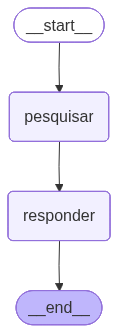

In [14]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
# Modo CUSTOM: receber dados arbitrários via get_stream_writer()
for chunk in app.stream(
    {"messages": [{"role": "user", "content": "Qual o clima em São Paulo?"}]},
    stream_mode="custom",
):
    print(chunk)

{'status': 'Pesquisando informações...'}
{'status': 'Pesquisa concluída.', 'dados': {'temperatura': 25, 'cidade': 'São Paulo'}}
{'status': 'Gerando resposta...'}


Repare que recebemos exatamente os dicionários que passamos pro `writer()` dentro de cada nó. Primeiro o status de pesquisa, depois os dados encontrados, e por fim o status de geração de resposta. Isso dá um controle total sobre o que o usuário vê durante a execução.

In [16]:
# Custom + updates juntos
for chunk in app.stream(
    {"messages": [{"role": "user", "content": "Clima em São Paulo?"}]},
    stream_mode=["custom", "updates"],
):
    mode, data = chunk
    if mode == "custom":
        print(f"[custom] {data}")
    elif mode == "updates":
        for node_name in data:
            print(f"[update] node={node_name}")

[custom] {'status': 'Pesquisando informações...'}
[custom] {'status': 'Pesquisa concluída.', 'dados': {'temperatura': 25, 'cidade': 'São Paulo'}}
[update] node=pesquisar
[custom] {'status': 'Gerando resposta...'}
[update] node=responder


## Streaming assíncrono

Até agora usamos `.stream()`, que é síncrono. Pra colocar um agente em produção, geralmente precisamos da versão **assíncrona**: `.astream()`. A interface é idêntica, mas usa `async for` em vez de `for`. Isso é essencial quando o servidor precisa atender múltiplas requisições ao mesmo tempo.

In [17]:
# Streaming assíncrono (necessário para deploy)
import asyncio


async def stream_async():
    async for chunk in agente.astream(
        {"messages": [HumanMessage(content="Clima em Curitiba?")]},
        stream_mode="messages",
    ):
        msg, metadata = chunk
        if msg.content:
            print(msg.content, end="", flush=True)
    print()


await stream_async()

15°C, chuva leve, umidade 80%O clima em Curitiba está com temperatura de 15°C, chuva leve e umidade de 80%. Deseja sugestões de atividades ou restaurantes na cidade?


## Deploy com FastAPI

Agora vamos colocar nosso agente em produção. A abordagem mais comum é usar **FastAPI** com **Server-Sent Events (SSE)**. O servidor recebe a pergunta via POST, e em vez de retornar uma resposta única, ele abre um stream HTTP que vai enviando os tokens conforme são gerados.

O padrão SSE é simples: cada mensagem vem no formato `data: {...}\n\n`, e o cliente lê linha por linha. Quando o stream termina, enviamos `data: [DONE]`.

In [18]:
%%writefile ../server.py
"""Servidor FastAPI com streaming SSE para o agente."""
import json
import uvicorn
from dotenv import load_dotenv
from fastapi import FastAPI
from fastapi.responses import StreamingResponse
from pydantic import BaseModel

from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage

load_dotenv()


@tool
def consultar_clima(cidade: str) -> str:
    """Consulta a previsão do tempo para uma cidade."""
    previsoes = {
        "são paulo": "25°C, parcialmente nublado",
        "rio de janeiro": "32°C, ensolarado",
        "curitiba": "15°C, chuva leve",
    }
    return previsoes.get(cidade.lower(), f"Previsão não disponível para {cidade}.")


agente = create_agent(
    model="gpt-4.1-nano",
    tools=[consultar_clima],
    system_prompt="Você é um assistente meteorológico. Responda em português.",
)

app = FastAPI()


class Pergunta(BaseModel):
    mensagem: str


async def gerar_stream(mensagem: str):
    async for chunk in agente.astream(
        {"messages": [HumanMessage(content=mensagem)]},
        stream_mode="messages",
    ):
        msg, metadata = chunk
        if msg.content and metadata.get("langgraph_node") == "model":
            yield f"data: {json.dumps({'token': msg.content})}\n\n"
    yield "data: [DONE]\n\n"


@app.post("/chat")
async def chat(pergunta: Pergunta):
    return StreamingResponse(
        gerar_stream(pergunta.mensagem),
        media_type="text/event-stream",
    )


if __name__ == "__main__":
    uvicorn.run(app, host="0.0.0.0", port=8000)

Overwriting ../server.py


In [19]:
# Para rodar o servidor em outro terminal:
# uv run python server.py
print("Rode em outro terminal: uv run python server.py")

Rode em outro terminal: uv run python server.py


O `StreamingResponse` do FastAPI é o que faz a mágica: ele consome nosso gerador assíncrono e envia cada chunk pro cliente via HTTP. O `media_type="text/event-stream"` diz ao navegador que se trata de um fluxo SSE.

Pra testar o servidor, a gente usa o `httpx` com streaming. O código abaixo faz um POST pro endpoint `/chat` e lê os tokens conforme chegam. Lembre de subir o servidor antes de rodar.

In [20]:
import json

import httpx


async def testar_servidor():
    async with httpx.AsyncClient(timeout=30) as client:
        async with client.stream(
            "POST",
            "http://localhost:8000/chat",
            json={"mensagem": "Qual o clima em São Paulo?"},
        ) as response:
            async for line in response.aiter_lines():
                if line.startswith("data: "):
                    data = line[6:]
                    if data == "[DONE]":
                        break
                    token = json.loads(data)["token"]
                    print(token, end="", flush=True)
    print()


# Descomente para testar (precisa do servidor rodando)
# await testar_servidor()

## Interface com Streamlit

FastAPI cuida do backend, mas pro usuário final a gente precisa de uma interface. O **Streamlit** é perfeito pra isso: com poucas linhas a gente cria um chat completo com streaming. O segredo está no `st.write_stream()`, que aceita um gerador e renderiza os tokens em tempo real.

In [21]:
%%writefile ../app_streamlit.py
"""App Streamlit com streaming do agente."""
import streamlit as st
from dotenv import load_dotenv

from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()


@tool
def consultar_clima(cidade: str) -> str:
    """Consulta a previsão do tempo para uma cidade."""
    previsoes = {
        "são paulo": "25°C, parcialmente nublado",
        "rio de janeiro": "32°C, ensolarado",
        "curitiba": "15°C, chuva leve",
    }
    return previsoes.get(cidade.lower(), f"Previsão não disponível para {cidade}.")


@st.cache_resource
def criar_agente():
    return create_agent(
        model="gpt-4.1-nano",
        tools=[consultar_clima],
        system_prompt="Você é um assistente meteorológico. Responda em português.",
        checkpointer=InMemorySaver(),
    )


agente = criar_agente()

st.title("Assistente Meteorológico")

if "messages" not in st.session_state:
    st.session_state.messages = []

for msg in st.session_state.messages:
    with st.chat_message(msg["role"]):
        st.write(msg["content"])

if prompt := st.chat_input("Pergunte sobre o clima..."):
    st.session_state.messages.append({"role": "user", "content": prompt})

    with st.chat_message("user"):
        st.write(prompt)

    with st.chat_message("assistant"):
        config = {"configurable": {"thread_id": "streamlit-session"}}

        def gerar_tokens():
            for chunk in agente.stream(
                {"messages": [HumanMessage(content=prompt)]},
                stream_mode="messages",
                config=config,
            ):
                msg, metadata = chunk
                if msg.content and metadata.get("langgraph_node") == "model":
                    yield msg.content

        resposta = st.write_stream(gerar_tokens())

    st.session_state.messages.append({"role": "assistant", "content": resposta})

Overwriting ../app_streamlit.py


In [22]:
# Para rodar o Streamlit:
# uv run streamlit run app_streamlit.py
print("Rode: uv run streamlit run app_streamlit.py")

Rode: uv run streamlit run app_streamlit.py


### Visibilidade de tools

Na versão anterior, o usuário só vê a resposta final. Mas quando o agente chama uma tool, pode demorar um pouco, e o usuário fica sem feedback. Nessa versão melhorada, a gente combina `stream_mode=["messages", "updates"]` pra mostrar qual ferramenta está sendo usada enquanto os tokens ainda não começaram a chegar.

In [23]:
%%writefile ../app_streamlit_tools.py
"""App Streamlit com visibilidade de tool calls."""
import streamlit as st
from dotenv import load_dotenv

from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()


@tool
def consultar_clima(cidade: str) -> str:
    """Consulta a previsão do tempo para uma cidade."""
    previsoes = {
        "são paulo": "25°C, parcialmente nublado",
        "rio de janeiro": "32°C, ensolarado",
        "curitiba": "15°C, chuva leve",
    }
    return previsoes.get(cidade.lower(), f"Previsão não disponível para {cidade}.")


@tool
def buscar_restaurantes(cidade: str, tipo: str) -> str:
    """Busca restaurantes em uma cidade por tipo de culinária."""
    return f"3 restaurantes de {tipo} em {cidade}: A, B, C."


@st.cache_resource
def criar_agente():
    return create_agent(
        model="gpt-4.1-nano",
        tools=[consultar_clima, buscar_restaurantes],
        system_prompt="Você é um assistente de viagem.",
        checkpointer=InMemorySaver(),
    )


agente = criar_agente()

st.title("Assistente de Viagem")

if "messages" not in st.session_state:
    st.session_state.messages = []

for msg in st.session_state.messages:
    with st.chat_message(msg["role"]):
        st.write(msg["content"])

if prompt := st.chat_input("Pergunte sobre viagem..."):
    st.session_state.messages.append({"role": "user", "content": prompt})

    with st.chat_message("user"):
        st.write(prompt)

    with st.chat_message("assistant"):
        config = {"configurable": {"thread_id": "streamlit-tools"}}
        status_container = st.empty()

        tool_calls_seen = []

        def gerar_tokens():
            for chunk in agente.stream(
                {"messages": [HumanMessage(content=prompt)]},
                stream_mode=["messages", "updates"],
                config=config,
            ):
                mode, data = chunk
                if mode == "updates":
                    for node_name, update in data.items():
                        if node_name == "tools":
                            for msg in update.get("messages", []):
                                tool_calls_seen.append(msg.name)
                                status_container.info(f"Ferramenta: {msg.name}")
                elif mode == "messages":
                    msg, metadata = data
                    if msg.content and metadata.get("langgraph_node") == "model":
                        yield msg.content

        resposta = st.write_stream(gerar_tokens())
        status_container.empty()

    st.session_state.messages.append({"role": "assistant", "content": resposta})

Overwriting ../app_streamlit_tools.py


In [24]:
print("Rode: uv run streamlit run app_streamlit_tools.py")

Rode: uv run streamlit run app_streamlit_tools.py


Com isso a gente cobriu o ciclo completo: desde entender por que streaming importa, passando por todos os modos do LangGraph (`values`, `updates`, `messages`, `custom`), até colocar tudo em produção com FastAPI e Streamlit. O padrão que vocês vão usar com mais frequência é o `stream_mode="messages"` filtrado por `langgraph_node == "model"` -- é ele que dá aquela experiência fluida de chat em tempo real.